[LangChain RAG Tutorial](https://python.langchain.com/docs/tutorials/rag/)  
[LangGraph Agentic RAG Tutorial](https://langchain-ai.github.io/langgraph/tutorials/rag/langgraph_agentic_rag/#7-assemble-the-graph)

# 1. Preparar documentos

In [16]:
import json
from pathlib import Path
from datetime import datetime
from langchain.docstore.document import Document
from langchain.document_loaders import JSONLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Lee cada elemento del array con jq_schema=".[]"
loader = JSONLoader(
    file_path=Path("../data/attendance_docs_enriched.json"),
    jq_schema=".[]",
    text_content=False          # page_content será la cadena JSON
)
docs_raw = loader.load()        # list[Document]

def normalize(doc: Document) -> tuple[Document, str]:
    # 🔑 Convertir el texto JSON a dict
    rec = json.loads(doc.page_content) if isinstance(doc.page_content, str) else doc.page_content

    texto = (
        f"Asistencia del {rec.get('fecha_human') or 'fecha desconocida'} "
        f"Legislatura: {rec['legislatura']} – "
        f"Congreso {rec['periodo_congreso']} | "
        f"Periodo anual {rec['periodo_anual']}."
        f"URL: {rec['url']}"
    )

    # 🗂️ Crear metadata limpio asegurando la URL y el ID original
    metadata = {
        "doc_id": rec.get("id"),  # 🆔 Guardar el ID original del JSON
        "sesion": rec.get("sesion"),
        "fecha": rec.get("fecha"),
        "legislatura": rec.get("legislatura"),
        "periodo_anual_inicio": rec.get("periodo_anual_inicio"),
        "periodo_anual_fin": rec.get("periodo_anual_fin"),
        "periodo_anual": rec.get("periodo_anual"),
        "numero_legislatura": rec.get("n_legislatura"),
        "pagina": rec.get("page"),
        "url": rec.get("url"),
        "version": datetime.now().strftime("%Y.%m.%d.%H.%M")  # 2024.12.26.15.30

    }

    # Retornar el documento Y su ID personalizado
    return Document(page_content=texto, metadata=metadata), rec.get("id")

# 🔧 Procesar documentos y extraer IDs personalizados
docs_and_ids = [normalize(d) for d in docs_raw]
docs = [doc for doc, _ in docs_and_ids]
custom_ids = [doc_id for _, doc_id in docs_and_ids]

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

print(f"{len(docs_raw)=}  {len(split_docs)=}")
print(f"Primeros 3 IDs personalizados: {custom_ids[:3]}")

len(docs_raw)=845  len(split_docs)=845
Primeros 3 IDs personalizados: ['3ebf3796-fcc9-4a5a-a1c6-cfe9ce68f267', 'ce02f1fd-5b61-44ae-829b-2b7c330b1940', '7772bc39-640e-444f-8bf7-fecd8efc30d1']


In [17]:
docs[0]

Document(metadata={'doc_id': '3ebf3796-fcc9-4a5a-a1c6-cfe9ce68f267', 'sesion': '937_pp2006_2011_pa2009_2010_leg1_page_13', 'fecha': '2009-10-07T15:38:00', 'legislatura': 'Primera Legislatura Ordinaria 2009-2010', 'periodo_anual_inicio': 2009, 'periodo_anual_fin': 2010, 'periodo_anual': '2009-2010', 'numero_legislatura': 1, 'pagina': 13, 'url': 'http://localhost:8080/asistencia/937_pp2006_2011_pa2009_2010_leg1_page_13.png', 'version': '2025.06.21.10.21'}, page_content='Asistencia del 07 Oct 2009 15:38 Legislatura: Primera Legislatura Ordinaria 2009-2010 – Congreso 2006-2011 | Periodo anual 2009-2010.URL: http://localhost:8080/asistencia/937_pp2006_2011_pa2009_2010_leg1_page_13.png')

# 2. Indexar documentos

In [18]:
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vector_store = InMemoryVectorStore(embeddings)

# 🆔 Usar IDs personalizados al indexar documentos
document_ids = vector_store.add_documents(docs, ids=custom_ids)

print(f"✅ Documentos indexados con IDs personalizados")
print(f"Total de documentos: {len(document_ids)}")
print(f"IDs utilizados (primeros 3): {document_ids[:3]}")

✅ Documentos indexados con IDs personalizados
Total de documentos: 845
IDs utilizados (primeros 3): ['3ebf3796-fcc9-4a5a-a1c6-cfe9ce68f267', 'ce02f1fd-5b61-44ae-829b-2b7c330b1940', '7772bc39-640e-444f-8bf7-fecd8efc30d1']


In [19]:
# 🔍 Verificar que ahora usamos los IDs del JSON original
print("IDs originales vs IDs asignados:")
for i in range(3):
    print(f"  Original: {custom_ids[i]}")
    print(f"  Asignado: {document_ids[i]}")
    print(f"  ¿Coinciden? {custom_ids[i] == document_ids[i]}")
    print("---")

IDs originales vs IDs asignados:
  Original: 3ebf3796-fcc9-4a5a-a1c6-cfe9ce68f267
  Asignado: 3ebf3796-fcc9-4a5a-a1c6-cfe9ce68f267
  ¿Coinciden? True
---
  Original: ce02f1fd-5b61-44ae-829b-2b7c330b1940
  Asignado: ce02f1fd-5b61-44ae-829b-2b7c330b1940
  ¿Coinciden? True
---
  Original: 7772bc39-640e-444f-8bf7-fecd8efc30d1
  Asignado: 7772bc39-640e-444f-8bf7-fecd8efc30d1
  ¿Coinciden? True
---


# 3. Recuperar y generar

In [20]:
from langchain_core.prompts import PromptTemplate

template = """Responde únicamente con la información exacta proporcionada en el contexto.
No inventes ni completes información que no esté explícitamente presente.
Incluye solo el asunto (si lo hay), la fecha o legislatura correspondiente, y la URL del documento.

{context}

Pregunta: {question}

Respuesta:"""

prompt = PromptTemplate.from_template(template)

In [21]:
example_messages = prompt.invoke(
    {"context": "{context}", "question": "{question}"}
).to_messages()

assert len(example_messages) == 1
print(example_messages[0].content)

Responde únicamente con la información exacta proporcionada en el contexto.
No inventes ni completes información que no esté explícitamente presente.
Incluye solo el asunto (si lo hay), la fecha o legislatura correspondiente, y la URL del documento.

{context}

Pregunta: {question}

Respuesta:


In [22]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("gpt-4o-mini", model_provider="openai")

In [23]:
from langchain_core.documents import Document
from typing_extensions import List, TypedDict


class State(TypedDict):
    question: str
    context: List[Document]
    answer: str

def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}


def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}

In [24]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

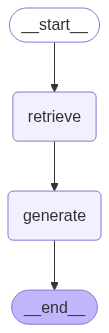

In [25]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
result = graph.invoke({"question": "Que asistencias tienes disponibles?"})

print(f'Context: {result["context"]}\n\n')
print(f'Answer: {result["answer"]}')

Context: [Document(id='1ad6dc73-9f40-4b51-9106-c32a2eff1781', metadata={'doc_id': '1ad6dc73-9f40-4b51-9106-c32a2eff1781', 'sesion': '102_pp2021_2026_pa2023_2024_leg1_page_62', 'fecha': '2023-11-09T21:44:00', 'legislatura': 'Primera Legislatura Ordinaria 2023-2024', 'periodo_anual_inicio': 2023, 'periodo_anual_fin': 2024, 'periodo_anual': '2023-2024', 'numero_legislatura': 1, 'pagina': 62, 'url': 'http://localhost:8080/asistencia/102_pp2021_2026_pa2023_2024_leg1_page_62.png', 'version': '2025.06.21.10.21'}, page_content='Asistencia del 09 Nov 2023 21:44 Legislatura: Primera Legislatura Ordinaria 2023-2024 – Congreso 2021-2026 | Periodo anual 2023-2024.URL: http://localhost:8080/asistencia/102_pp2021_2026_pa2023_2024_leg1_page_62.png'), Document(id='ea239fa4-2dd5-4611-bbc5-cb12f7a620bb', metadata={'doc_id': 'ea239fa4-2dd5-4611-bbc5-cb12f7a620bb', 'sesion': '282_pp2016_2021_pa2021_2022_leg4_page_26', 'fecha': '2021-07-09T18:21:00', 'legislatura': 'Cuarta Legislatura Ordinaria 2020-2021', 

# 4. Ejemplos de operaciones con ID

In [27]:
# 🗑️ Ejemplo 1: Eliminar un documento por ID específico
print("=== EJEMPLO 1: ELIMINAR DOCUMENTO POR ID ===")

# Verificar cuántos documentos tenemos antes
docs_before = vector_store.similarity_search("asistencia", k=1000)
print(f"📊 Documentos antes de eliminar: {len(docs_before)}")

# Tomar el primer ID para eliminar
id_to_delete = custom_ids[0]
print(f"🎯 ID a eliminar: {id_to_delete}")

# Mostrar información del documento que vamos a eliminar
doc_to_delete = docs[0]
print(f"📄 Documento a eliminar: {doc_to_delete.metadata['sesion']}")
print(f"🗓️ Fecha: {doc_to_delete.metadata['fecha']}")
print(f"🔢 Versión: {doc_to_delete.metadata['version']}")

# Eliminar el documento
deletion_result = vector_store.delete(ids=[id_to_delete])
print(f"✅ Resultado de eliminación: {deletion_result}")

# Verificar que se eliminó
docs_after = vector_store.similarity_search("asistencia", k=1000)
print(f"📊 Documentos después de eliminar: {len(docs_after)}")
print(f"✅ Documentos eliminados: {len(docs_before) - len(docs_after)}")

print("\n" + "="*60 + "\n")


=== EJEMPLO 1: ELIMINAR DOCUMENTO POR ID ===
📊 Documentos antes de eliminar: 845
🎯 ID a eliminar: 3ebf3796-fcc9-4a5a-a1c6-cfe9ce68f267
📄 Documento a eliminar: 937_pp2006_2011_pa2009_2010_leg1_page_13
🗓️ Fecha: 2009-10-07T15:38:00
🔢 Versión: 2025.06.21.10.21
✅ Resultado de eliminación: None
📊 Documentos después de eliminar: 844
✅ Documentos eliminados: 1




In [28]:
# 🔄 Ejemplo 2: Actualizar un documento existente (ELIMINAR + AGREGAR)
print("=== EJEMPLO 2: ACTUALIZAR DOCUMENTO EXISTENTE ===")
print("⚠️ IMPORTANTE: En vector stores NO se puede 'actualizar' directamente.")
print("   El proceso correcto es: 1) ELIMINAR el documento, 2) AGREGAR el nuevo")

# Tomar el segundo documento para actualizar
id_to_update = custom_ids[1]
original_doc = docs[1]

print(f"\n🎯 ID a actualizar: {id_to_update}")
print(f"📄 Documento original: {original_doc.metadata['sesion']}")
print(f"📝 Contenido original (parcial): {original_doc.page_content[:100]}...")
print(f"🔢 Versión original: {original_doc.metadata['version']}")

# Contar documentos antes del proceso
docs_before_update = vector_store.similarity_search("asistencia", k=1000)
print(f"📊 Documentos antes de actualizar: {len(docs_before_update)}")

# PASO 1: ELIMINAR el documento existente
print("\n🗑️ PASO 1: Eliminando documento existente...")
deletion_result = vector_store.delete(ids=[id_to_update])
print(f"✅ Documento eliminado: {deletion_result}")

# PASO 2: CREAR la nueva versión del documento
print("\n🔄 PASO 2: Creando nueva versión...")
updated_content = (
    f"🔄 ACTUALIZADO - Asistencia del {original_doc.metadata.get('fecha')} "
    f"Legislatura: {original_doc.metadata.get('legislatura')} [MODIFICADO] - "
    f"Congreso 2021-2026 | Periodo anual {original_doc.metadata.get('periodo_anual')}. "
    f"URL: {original_doc.metadata.get('url')}"
)

# Crear metadatos actualizados manteniendo el esquema
updated_metadata = original_doc.metadata.copy()
updated_metadata["version"] = datetime.now().strftime("%Y.%m.%d.%H.%M")  # Nueva versión con timestamp actual

updated_doc = Document(
    page_content=updated_content,
    metadata=updated_metadata
)

# PASO 3: AGREGAR el documento actualizado con el mismo ID
print("➕ PASO 3: Agregando documento actualizado...")
add_result = vector_store.add_documents([updated_doc], ids=[id_to_update])
print(f"✅ Documento agregado con ID: {add_result[0]}")

# PASO 4: VERIFICAR la actualización
print("\n🔍 PASO 4: Verificando actualización...")
docs_after_update = vector_store.similarity_search("asistencia", k=1000)
print(f"📊 Documentos después de actualizar: {len(docs_after_update)}")
print(f"✅ Total de documentos se mantiene: {len(docs_before_update) == len(docs_after_update)}")

# Buscar específicamente el documento actualizado
updated_search = vector_store.similarity_search("ACTUALIZADO MODIFICADO", k=1)
if updated_search:
    found_doc = updated_search[0]
    print(f"🔍 Documento encontrado con nueva versión: {found_doc.metadata['version']}")
    print(f"📝 Contenido actualizado verificado: {'ACTUALIZADO' in found_doc.page_content}")
else:
    print("❌ No se encontró el documento actualizado")

print("\n" + "="*60 + "\n")


=== EJEMPLO 2: ACTUALIZAR DOCUMENTO EXISTENTE ===
⚠️ IMPORTANTE: En vector stores NO se puede 'actualizar' directamente.
   El proceso correcto es: 1) ELIMINAR el documento, 2) AGREGAR el nuevo

🎯 ID a actualizar: ce02f1fd-5b61-44ae-829b-2b7c330b1940
📄 Documento original: 936_pp2006_2011_pa2009_2010_leg1_page_2
📝 Contenido original (parcial): Asistencia del 21 Oct 2009 21:48 Legislatura: Primera Legislatura Ordinaria 2009-2010 – Congreso 200...
🔢 Versión original: 2025.06.21.10.21
📊 Documentos antes de actualizar: 844

🗑️ PASO 1: Eliminando documento existente...
✅ Documento eliminado: None

🔄 PASO 2: Creando nueva versión...
➕ PASO 3: Agregando documento actualizado...
✅ Documento agregado con ID: ce02f1fd-5b61-44ae-829b-2b7c330b1940

🔍 PASO 4: Verificando actualización...
📊 Documentos después de actualizar: 844
✅ Total de documentos se mantiene: True
🔍 Documento encontrado con nueva versión: 2025.06.21.10.21
📝 Contenido actualizado verificado: True




In [29]:
# ➕ Ejemplo 3: Agregar un documento completamente nuevo
print("=== EJEMPLO 3: AGREGAR DOCUMENTO NUEVO ===")

# Contar documentos antes de agregar
docs_before_add = vector_store.similarity_search("asistencia", k=1000)
print(f"📊 Documentos antes de agregar: {len(docs_before_add)}")

# Crear un documento completamente nuevo
new_id = "nuevo_documento_2024_test"
new_doc = Document(
    page_content="🆕 NUEVO DOCUMENTO - Asistencia de prueba del 26 Dic 2024 15:30 "
                "Legislatura: Sesión Extraordinaria de Prueba – "
                "Congreso 2024-2029 | Periodo anual 2024-2025. "
                "URL: http://localhost:8080/test_nuevo_documento.png",
    metadata={
        "doc_id": new_id,
        "sesion": "test_2024_pa2024_2025_extraordinaria_page_1",
        "fecha": "2024-12-26T15:30:00",
        "legislatura": "Sesión Extraordinaria de Prueba",
        "periodo_anual_inicio": 2024,
        "periodo_anual_fin": 2025,
        "periodo_anual": "2024-2025",
        "numero_legislatura": 999,  # Número especial para prueba
        "pagina": 1,
        "url": "http://localhost:8080/test_nuevo_documento.png",
        "version": datetime.now().strftime("%Y.%m.%d.%H.%M")
    }
)

print(f"🆔 Nuevo ID: {new_id}")
print(f"📄 Nueva sesión: {new_doc.metadata['sesion']}")
print(f"🔢 Versión: {new_doc.metadata['version']}")

# Agregar el nuevo documento
new_doc_result = vector_store.add_documents([new_doc], ids=[new_id])
print(f"✅ Documento agregado con ID: {new_doc_result[0]}")

# Verificar que se agregó
docs_after_add = vector_store.similarity_search("asistencia", k=1000)
print(f"📊 Documentos después de agregar: {len(docs_after_add)}")
print(f"✅ Documentos agregados: {len(docs_after_add) - len(docs_before_add)}")

# Buscar específicamente el nuevo documento
new_search = vector_store.similarity_search("NUEVO DOCUMENTO prueba", k=1)
if new_search:
    found_new_doc = new_search[0]
    print(f"🔍 Nuevo documento encontrado: {found_new_doc.metadata['doc_id']}")
    print(f"📝 Contenido verificado: {'NUEVO DOCUMENTO' in found_new_doc.page_content}")
else:
    print("❌ No se encontró el nuevo documento")

print("\n" + "="*60 + "\n")


=== EJEMPLO 3: AGREGAR DOCUMENTO NUEVO ===
📊 Documentos antes de agregar: 844
🆔 Nuevo ID: nuevo_documento_2024_test
📄 Nueva sesión: test_2024_pa2024_2025_extraordinaria_page_1
🔢 Versión: 2025.06.21.10.21
✅ Documento agregado con ID: nuevo_documento_2024_test
📊 Documentos después de agregar: 845
✅ Documentos agregados: 1
🔍 Nuevo documento encontrado: nuevo_documento_2024_test
📝 Contenido verificado: True




In [30]:
# 📋 Ejemplo 4: Operaciones adicionales con IDs
print("=== EJEMPLO 4: OPERACIONES ADICIONALES CON IDs ===")

# Verificar el estado final
final_docs = vector_store.similarity_search("asistencia", k=1000)
print(f"📊 Total final de documentos en el vector store: {len(final_docs)}")

# Eliminar múltiples documentos de una vez
print("\n🗑️ Eliminando múltiples documentos...")
if len(custom_ids) >= 13:
    ids_to_delete_multiple = custom_ids[10:13]  # Eliminar 3 documentos
else:
    ids_to_delete_multiple = custom_ids[-2:]    # Tomar los últimos 2 si no hay suficientes
    
print(f"IDs a eliminar: {ids_to_delete_multiple}")

try:
    deletion_result = vector_store.delete(ids=ids_to_delete_multiple)
    print(f"✅ Resultado de eliminación múltiple: {deletion_result}")
    
    # Verificar el estado después de eliminación múltiple
    docs_after_multiple_delete = vector_store.similarity_search("asistencia", k=1000)
    print(f"📊 Documentos después de eliminación múltiple: {len(docs_after_multiple_delete)}")
    print(f"✅ Documentos eliminados: {len(final_docs) - len(docs_after_multiple_delete)}")
    
except Exception as e:
    print(f"❌ Error en eliminación múltiple: {e}")

# Mostrar estadísticas finales
print(f"\n📈 ESTADÍSTICAS FINALES:")
print(f"   Documentos originales cargados: {len(docs)}")
print(f"   Documentos en vector store actual: {len(vector_store.similarity_search('asistencia', k=1000))}")
print(f"   Operaciones realizadas: Eliminación, Actualización, Inserción")

print("\n✅ Todos los ejemplos de operaciones CRUD con IDs completados exitosamente!")


=== EJEMPLO 4: OPERACIONES ADICIONALES CON IDs ===
📊 Total final de documentos en el vector store: 845

🗑️ Eliminando múltiples documentos...
IDs a eliminar: ['570f12ce-9240-4b52-8849-311035551fe3', '92ead463-40eb-4d14-9371-adbc865789ee', '2d34992c-8909-4f58-979e-756b457bca38']
✅ Resultado de eliminación múltiple: None
📊 Documentos después de eliminación múltiple: 842
✅ Documentos eliminados: 3

📈 ESTADÍSTICAS FINALES:
   Documentos originales cargados: 845
   Documentos en vector store actual: 842
   Operaciones realizadas: Eliminación, Actualización, Inserción

✅ Todos los ejemplos de operaciones CRUD con IDs completados exitosamente!
